In [1]:

import torch
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd

import json
import sys
import os
models_path = os.path.abspath(os.path.join('models'))
sys.path.append(models_path)

from DKT.dkt_model import DKT

In [6]:

# Load the configuration file
with open('data/models/best_dkt_config_skills_e2.json', 'r') as f:
    config = json.load(f)

# Step 3: Instantiate the model
model = DKT(**config['models_params'])

# Step 4: Load the saved parameters
# Step 4: Load the saved parameters
model.load_state_dict(torch.load('data/models/best_dkt_model_skills_e2.pth', map_location=torch.device('cpu')))
model.eval()  # Set the model to evaluation mode

# Step 5: Use the model to generate embeddings
def generate_embeddings(inputs):
    with torch.no_grad():
        embedded = model.embedding(inputs[:, :, 0] * 2 - inputs[:, :, 1])
        return embedded


C:\Users\bokovacs\AppData\Local\Temp\ipykernel_13604\2524156025.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('data/models/best_dkt_m

In [7]:
num_embeddings = int((model.embedding.num_embeddings - 1) / 2)
embedding_dim = model.embedding.embedding_dim

In [26]:
# Step 1: Create a DataFrame with `answer_id` from 1 to `num_embeddings` and `correct` set to 1
df_skills = pd.read_csv('data/preprocessed/skills_df.csv', index_col=0)

# Step 2: Calculate embeddings for each `skill_id`
# Create a tensor with the `answer_id` values, reshape to match input shape and get the embeddings
input_tensor = torch.tensor([[[i, 1] for i in range(1, num_embeddings + 1)]]).long()  # Shape: (1, num_embeddings, 2)

embeddings = generate_embeddings(input_tensor)  # Shape: (1, num_embeddings, embedding_dim)
embeddings = embeddings.squeeze(0)  # Remove the batch dimension to shape (num_embeddings, embedding_dim)

# Step 3: Add the calculated embeddings as columns to the DataFrame
# Convert embeddings to a list and add each dimension as a new column
embedding_list = embeddings.tolist()  # Shape: (num_embeddings, embedding_dim)
embedding_df = pd.DataFrame(embedding_list, columns=[f'embed_{i+1}' for i in range(embedding_dim)])

# Concatenate `df` with the embedding DataFrame
df_skills = pd.concat([df_skills, embedding_df], axis=1)

# Display the resulting DataFrame
print(df_skills.head())  # Print the first few rows to check the structure

df_skills = df_skills.dropna()


   skill_id_reindexed                   skill_name   embed_1   embed_2
0                   1              Box and Whisker -0.386309 -1.123497
1                   2                 Circle Graph  0.124195  0.623891
2                   3  Histogram as Table or Graph -0.194414 -1.398285
3                   4                  Number Line -1.092637 -1.505865
4                   5                 Scatter Plot -0.620561  1.245547


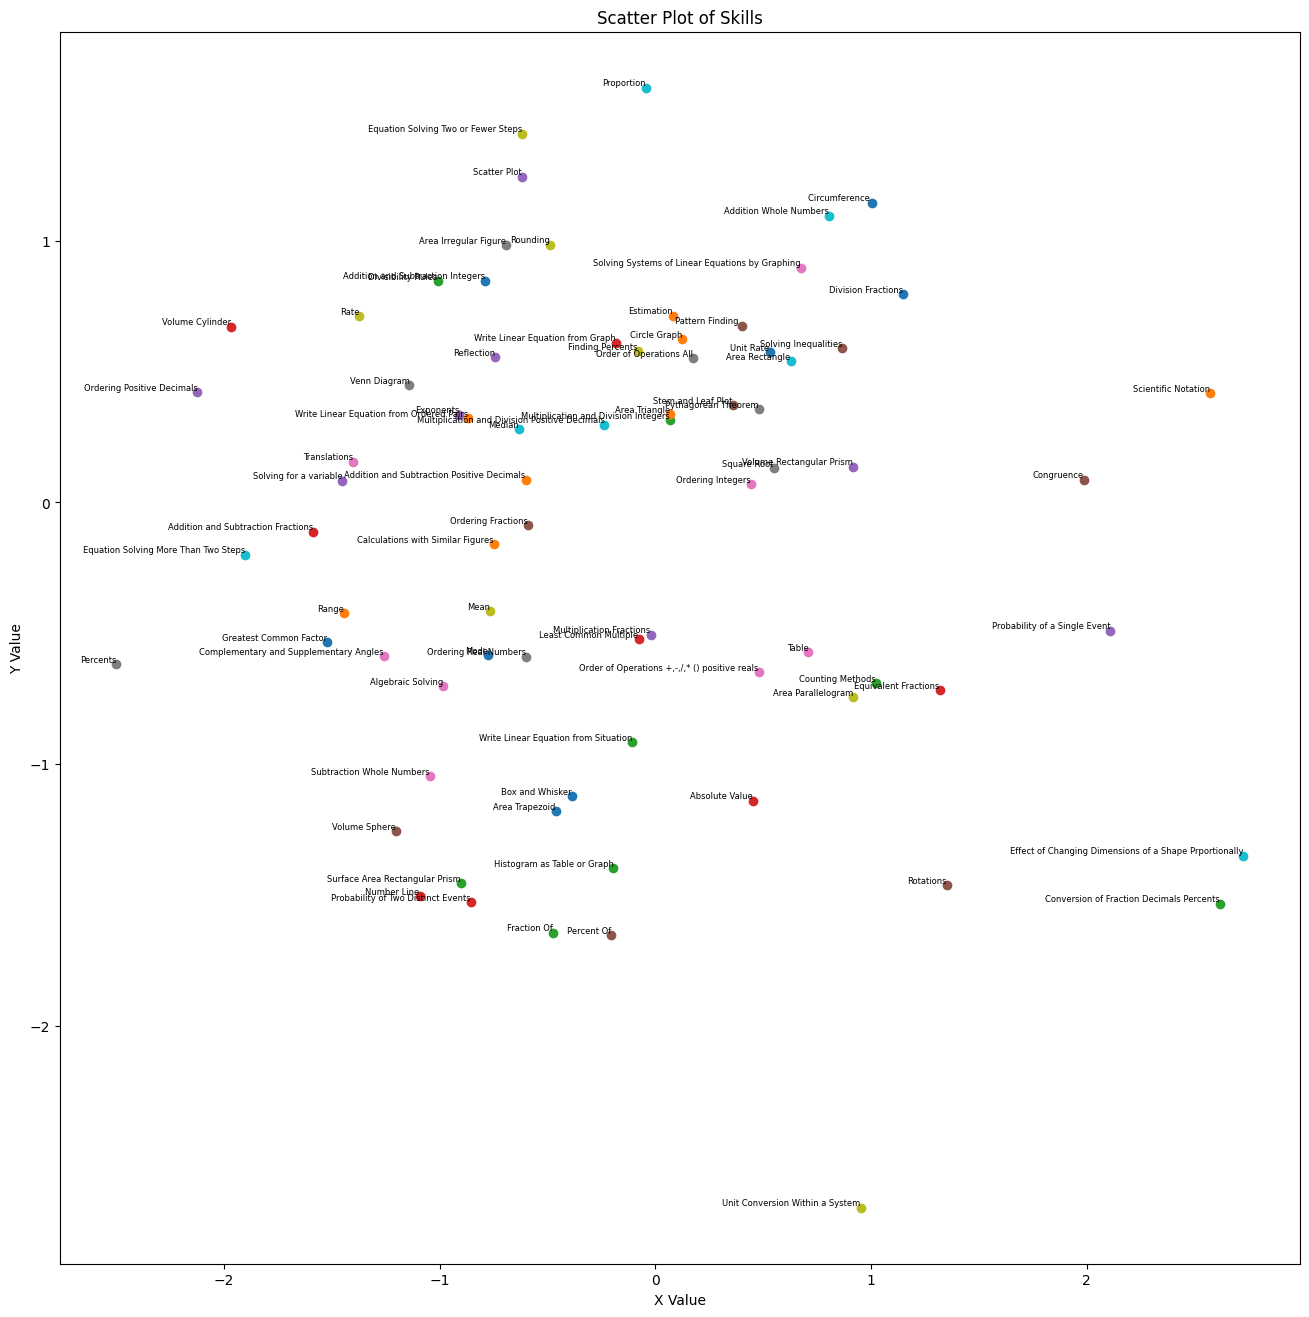

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a scatter plot
plt.figure(figsize=(16, 16))

# Plot each scatter point and annotate it with its 'skill_name'
for i, row in df_skills.iterrows():
    plt.scatter(row['embed_1'], row['embed_2'])  # You can customize color and marker
    plt.text(row['embed_1'], row['embed_2'], row['skill_name'], fontsize=6, ha='right', va='bottom')

plt.xlabel('X Value')
plt.ylabel('Y Value')
plt.title('Scatter Plot of Skills')
plt.show()


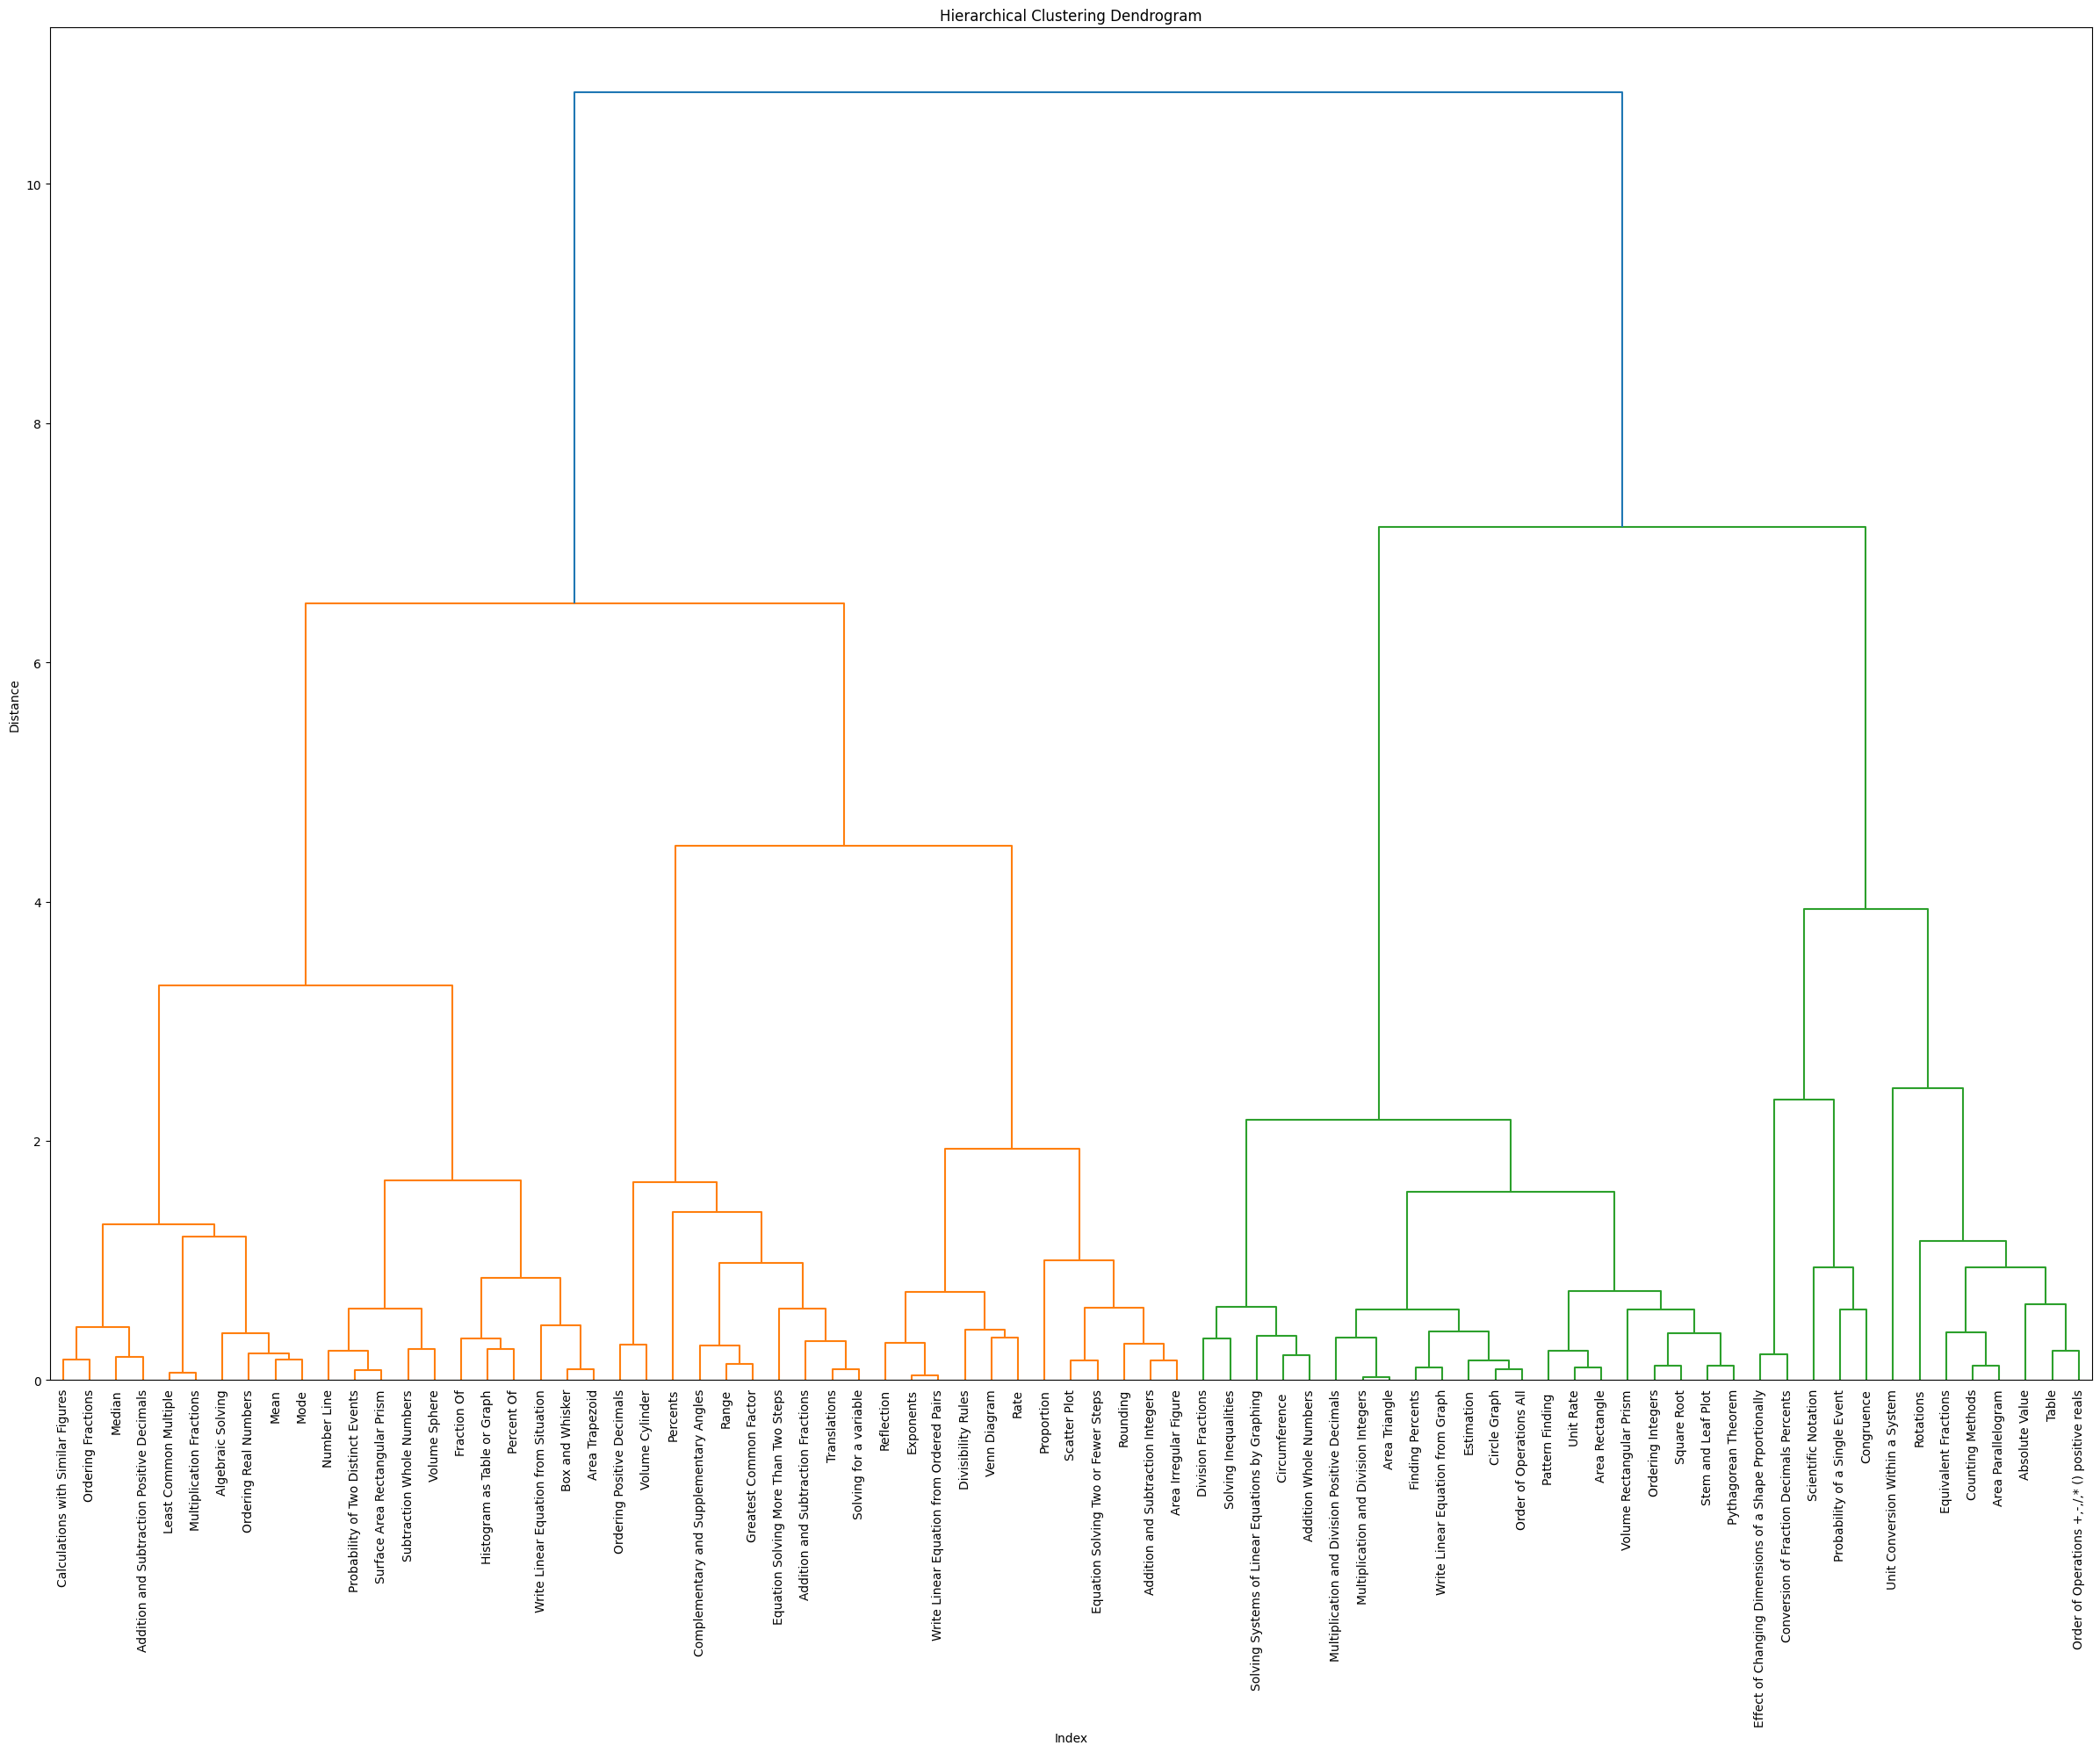

In [35]:
import scipy.cluster.hierarchy as sch


# Calculate the linkage matrix
linkage_matrix = sch.linkage(df_skills[['embed_1', 'embed_2']], method='ward')

# Plot the dendrogram
plt.figure(figsize=(30, 20))
sch.dendrogram(linkage_matrix, labels=df_skills['skill_name'].values, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.show()


No useful results - switching to train on a skill level instead of an answer level.